# Aurora 1.5 - flash-aurora Engine

Same forecast flow as the upstream Microsoft Aurora 1.5 example (ERA5 2023-01-01, extended surface fields), using `AuroraEngine` / `DataDownloader`.

- **Deterministic preset:** `aurora_v1p5` (`AuroraV1p5`, `aurora-0.25-v1.5.ckpt`)
- **Ensemble preset:** `aurora_v1p5_ensemble` (`AuroraV1p5Ensemble`, `aurora-0.25-v1.5-ensemble.ckpt`)
- **Checkpoint / static:** HF repo `ikwessel/aurora-1.5` (ensemble uses a pinned HF revision)
- **IC:** CDS ERA5 extended surface + pressure levels, HF static pickle, computed `insolation`
- **Hourly:** pass `fine_lead_times=[1, 2, 3, 4, 5, 6]` to `rollout_stream` / `rollout_and_export`
- **Visualise:** 2t vs ERA5 (+ bias), hourly strip, multi-field surface, Z500, optional ensemble spread

> ERA5 is for the tutorial only. Upstream notes the model is fine-tuned on IFS, so ERA5 skill is illustrative.

> **Asset root:** default is `./assets` under the working directory. Here we use the data disk in developing environment; comment `ASSET_ROOT = Path("/root/autodl-tmp/aurora")` in the setup cell to use your own disk.

## Prerequisites

1. CDS credentials for ERA5 single-levels and pressure-levels (`CDSAPI_KEY`, `~/.cdsapirc`, or `ensure(..., prompt=True)`).
2. Checkpoint / static pickle under `ASSET_ROOT`, or Hugging Face download. If `huggingface.co` is unreachable, set `USE_HF_MIRROR = True` in the setup cell.
3. GPU VRAM similar to other 0.25 deg global Aurora tutorials.


## Set up engine


In [1]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "aurora_v1p5"
# Match upstream tutorial date: history 00:00 + 06:00 -> IC valid time 06:00.
VALID_TIME = datetime(2023, 1, 1, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional - absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision="bf16_mixed@fp32" # use the fastest inference precision
)

print("source:", engine.config.source.name)
print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))


/root/flash-aurora/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint: ~/autodl-tmp/aurora/aurora-0.25-v1.5.ckpt
source: cds_era5_v1p5
cache_dir: ~/autodl-tmp/aurora/era5_v1p5
asset_root: ~/autodl-tmp/aurora


## 1. Download ERA5 V1p5 fields (CDS)

`DataDownloader.ensure()` retrieves the extended surface set and standard atmospheric levels into `<ASSET_ROOT>/era5_v1p5/`. Static land fields are loaded later from the HF pickle.


In [2]:
import os
from pathlib import Path

from flash_aurora.engine.ingress.download.paths import read_cdsapirc_key

missing_files = downloader.missing(VALID_TIME)
cds_api_key = (
    os.environ.get("CDSAPI_KEY", "").strip()
    or read_cdsapirc_key()
    or None
)
has_cdsapirc = Path.home().joinpath(".cdsapirc").is_file()
if missing_files:
    print("Downloading missing ERA5 V1p5 files:", missing_files)
    result = downloader.ensure(
        VALID_TIME,
        cds_api_key=cds_api_key,
        prompt=cds_api_key is None and not has_cdsapirc,
    )
else:
    print("ERA5 V1p5 cache complete, skipping download")
    result = downloader.ensure(VALID_TIME)

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


ERA5 V1p5 cache complete, skipping download
downloaded: ()
skipped: ('surface', 'atmospheric')
  surface: ~/autodl-tmp/aurora/era5_v1p5/2023-01-01-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/era5_v1p5/2023-01-01-atmospheric.nc


## 2. Build IC, load, rollout

`CdsEra5V1p5Adapter` maps CDS short names to Aurora fields, inserts `insolation`, and attaches the 36-field static pickle. Output-only surface vars are not required in the IC.


In [3]:
from flash_aurora.engine.ingress.adapters import IngestRequest

request = IngestRequest(
    valid_time=VALID_TIME,
    time_index=TIME_INDEX,
    cache_dir=downloader.resolve_cache_dir(),
)

batch = InitialConditionBuilder(engine.config).from_source(request)
print("surf vars:", len(batch.surf_vars), "static:", len(batch.static_vars))
print("IC time:", batch.metadata.time)

engine.load(rollout_steps=ROLLOUT_STEPS)
print("loaded model:", type(engine.model).__name__)
preds = [pred.to("cpu") for pred in engine.rollout_stream(batch, ROLLOUT_STEPS)]
print("rollout steps:", len(preds))
print("pred surf keys (sample):", sorted(preds[0].surf_vars)[:8], "...")


surf vars: 19 static: 36
IC time: (datetime.datetime(2023, 1, 1, 6, 0),)
loaded model: AuroraV1p5
rollout steps: 2
pred surf keys (sample): ['100u', '100v', '10u', '10v', '2d', '2t', 'blh', 'ci'] ...


## 3. Hourly fine lead times

Aurora 1.5 supports sub-6h leads. Within each main AR step, all fine leads are initialised from the same previous state; only the **last** fine lead (must equal 6 h) advances the autoregressive input.

Yield count is `ROLLOUT_STEPS * len(FINE_LEAD_TIMES)`.


In [4]:
FINE_LEAD_TIMES = [1, 2, 3, 4, 5, 6]

hourly_preds = [
    pred.to("cpu")
    for pred in engine.rollout_stream(
        batch,
        ROLLOUT_STEPS,
        fine_lead_times=FINE_LEAD_TIMES,
    )
]
print("hourly yields:", len(hourly_preds))
print("valid times:", [p.metadata.time[-1] for p in hourly_preds[:6]], "...")

# Optional NetCDF export (sequential filenames; times live in metadata):
# EXPORT_DIR = ASSET_ROOT / "output" / PRESET / "hourly"
# paths = list(engine.rollout_and_export(
#     batch,
#     ROLLOUT_STEPS,
#     export_dir=EXPORT_DIR,
#     fine_lead_times=FINE_LEAD_TIMES,
# ))
# print("wrote", len(paths), "files under", safe_path(EXPORT_DIR))


hourly yields: 12
valid times: [datetime.datetime(2023, 1, 1, 7, 0), datetime.datetime(2023, 1, 1, 8, 0), datetime.datetime(2023, 1, 1, 9, 0), datetime.datetime(2023, 1, 1, 10, 0), datetime.datetime(2023, 1, 1, 11, 0), datetime.datetime(2023, 1, 1, 12, 0)] ...


## 4. Visualise forecasts

Plots use the **hourly** roll-out (`hourly_preds`) so Aurora 1.5's sub-6h leads are visible. ERA5 truth comes from the same CDS NetCDF cache as the IC (00/06/12/18 UTC on 2023-01-01). With init at 06 UTC we can compare T+6h (12 UTC) and T+12h (18 UTC).


In [5]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

SURFACE_NC = result.paths["surface"]
ATMOS_NC = result.paths["atmospheric"]
# Explicit netcdf4 avoids xarray probing cfgrib (ecCodes warning on Linux wheels).
era5_surf = xr.open_dataset(SURFACE_NC, engine="netcdf4")
era5_atmos = xr.open_dataset(ATMOS_NC, engine="netcdf4")

# Hourly yields: index i -> lead i+1 hours from VALID_TIME (06 UTC).
LEAD_T6, LEAD_T12 = 5, 11  # T+6h, T+12h within the first two AR windows
ERA5_T12, ERA5_T18 = 2, 3  # 12:00 and 18:00 on 2023-01-01


def _field_2d(pred, name: str) -> np.ndarray:
    return pred.surf_vars[name][0, 0].detach().cpu().numpy()


def _atmos_level(pred, name: str, level_hpa: float) -> np.ndarray:
    levels = list(pred.metadata.atmos_levels)
    key = level_hpa if level_hpa in levels else int(level_hpa)
    idx = levels.index(key)
    return pred.atmos_vars[name][0, 0, idx].detach().cpu().numpy()


def _era5_surf(var: str, time_idx: int) -> np.ndarray:
    return np.asarray(era5_surf[var].isel(valid_time=time_idx).values)


def _era5_z500(time_idx: int) -> np.ndarray:
    return np.asarray(
        era5_atmos["z"].sel(pressure_level=500).isel(valid_time=time_idx).values
    )


def _match_pred_grid(truth: np.ndarray, pred: np.ndarray) -> np.ndarray:
    """Crop ERA5 to the model output grid (Aurora drops lat rows not divisible by patch_size)."""
    height, width = pred.shape[-2:]
    return truth[..., :height, :width]


def _imshow(ax, data: np.ndarray, *, vmin=None, vmax=None, cmap="viridis", title: str = ""):
    image = ax.imshow(data, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper", aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    return image


print("ERA5 surface times:", [str(t)[:16] for t in era5_surf.valid_time.values])
print(
    "hourly_preds:",
    len(hourly_preds),
    "first/last:",
    hourly_preds[0].metadata.time[-1],
    hourly_preds[-1].metadata.time[-1],
)


ERA5 surface times: ['2023-01-01T00:00', '2023-01-01T06:00', '2023-01-01T12:00', '2023-01-01T18:00']
hourly_preds: 12 first/last: 2023-01-01 07:00:00 2023-01-01 18:00:00


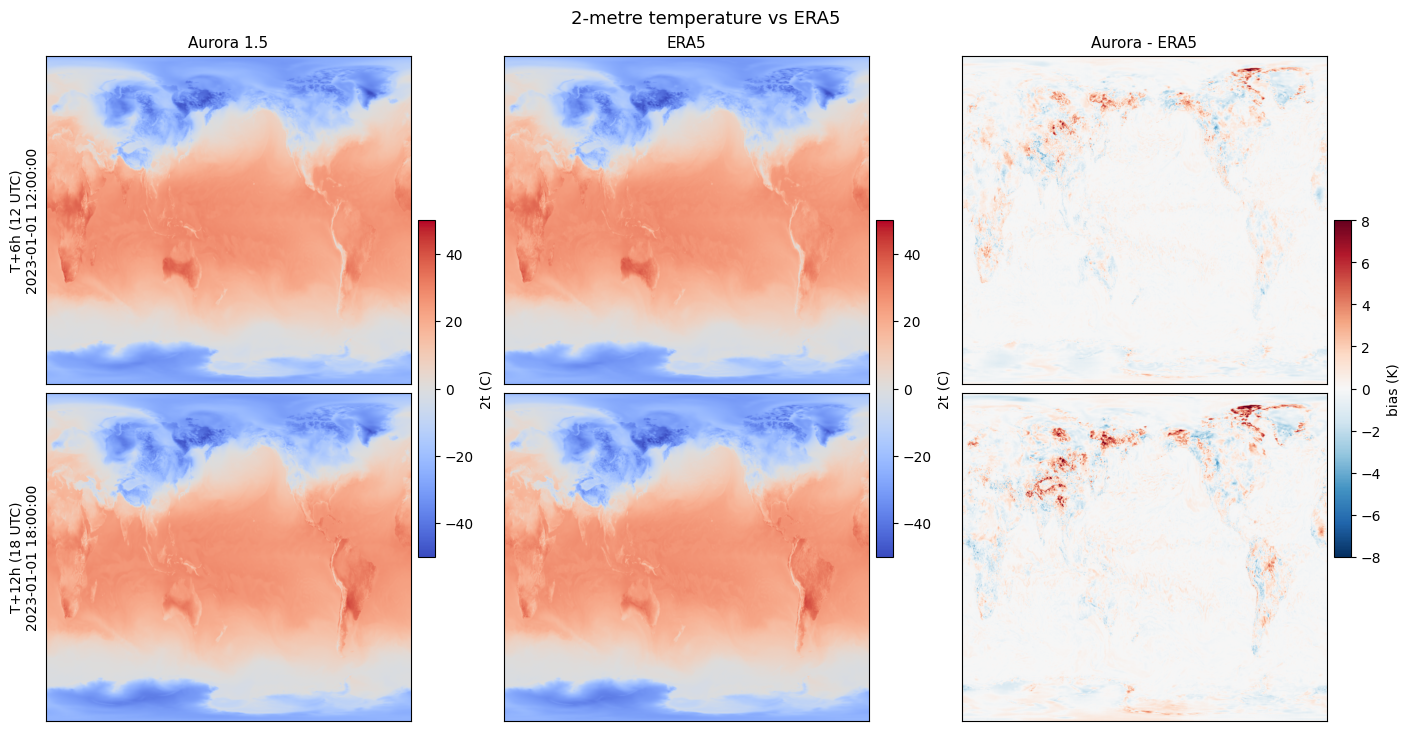

In [6]:
# 2-metre temperature: Aurora | ERA5 | bias (K) at T+6h and T+12h
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2), constrained_layout=True)
t2m_rows = [
    (LEAD_T6, ERA5_T12, "T+6h (12 UTC)"),
    (LEAD_T12, ERA5_T18, "T+12h (18 UTC)"),
]
for row, (pred_idx, era5_idx, label) in enumerate(t2m_rows):
    pred = hourly_preds[pred_idx]
    aurora = _field_2d(pred, "2t") - 273.15
    truth = _match_pred_grid(_era5_surf("t2m", era5_idx) - 273.15, aurora)
    bias = aurora - truth
    im0 = _imshow(axes[row, 0], aurora, vmin=-50, vmax=50, cmap="coolwarm", title="Aurora 1.5" if row == 0 else "")
    im1 = _imshow(axes[row, 1], truth, vmin=-50, vmax=50, cmap="coolwarm", title="ERA5" if row == 0 else "")
    im2 = _imshow(axes[row, 2], bias, vmin=-8, vmax=8, cmap="RdBu_r", title="Aurora - ERA5" if row == 0 else "")
    axes[row, 0].set_ylabel(f"{label}\n{pred.metadata.time[-1]}", fontsize=10)

fig.colorbar(im0, ax=axes[:, 0], fraction=0.046, pad=0.02, label="2t (C)")
fig.colorbar(im1, ax=axes[:, 1], fraction=0.046, pad=0.02, label="2t (C)")
fig.colorbar(im2, ax=axes[:, 2], fraction=0.046, pad=0.02, label="bias (K)")
fig.suptitle("2-metre temperature vs ERA5", fontsize=13)
plt.show()


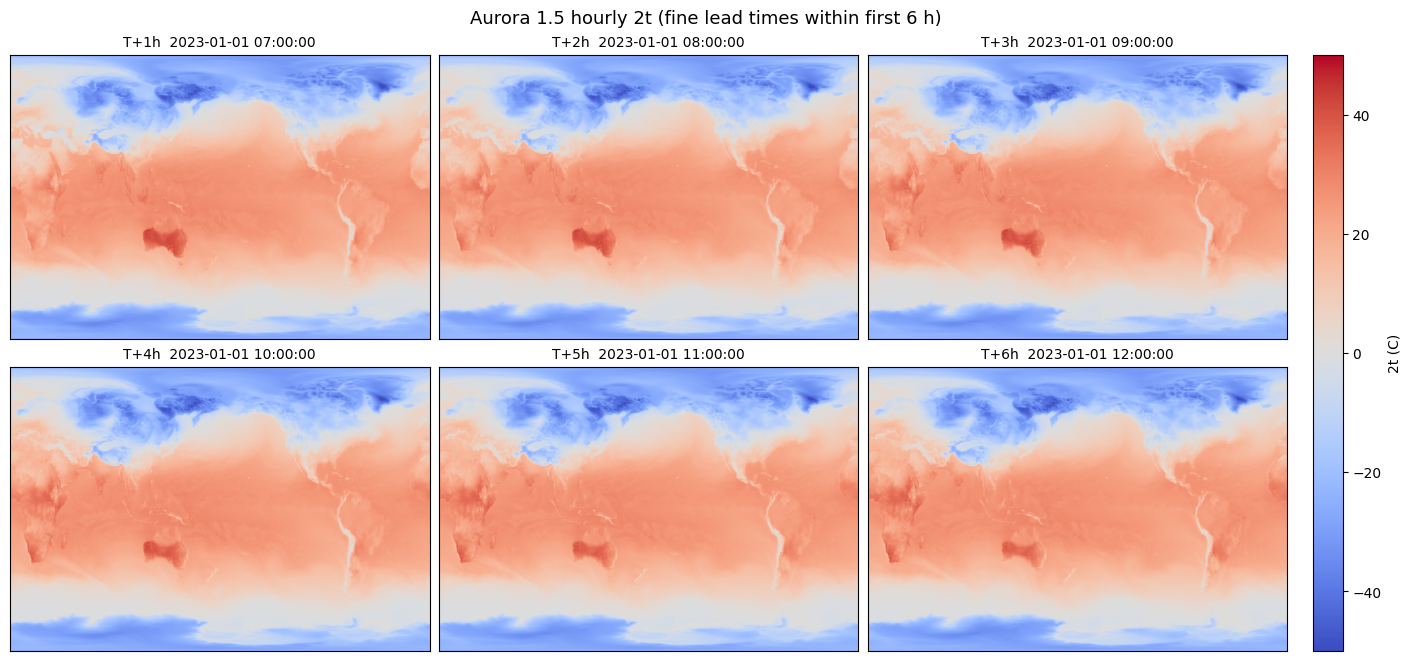

In [7]:
# Hourly 2t evolution for the first AR window (T+1h ... T+6h)
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    pred = hourly_preds[i]
    field = _field_2d(pred, "2t") - 273.15
    im = _imshow(ax, field, vmin=-50, vmax=50, cmap="coolwarm")
    ax.set_title(f"T+{i + 1}h  {pred.metadata.time[-1]}", fontsize=10)
fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="2t (C)")
fig.suptitle("Aurora 1.5 hourly 2t (fine lead times within first 6 h)", fontsize=13)
plt.show()


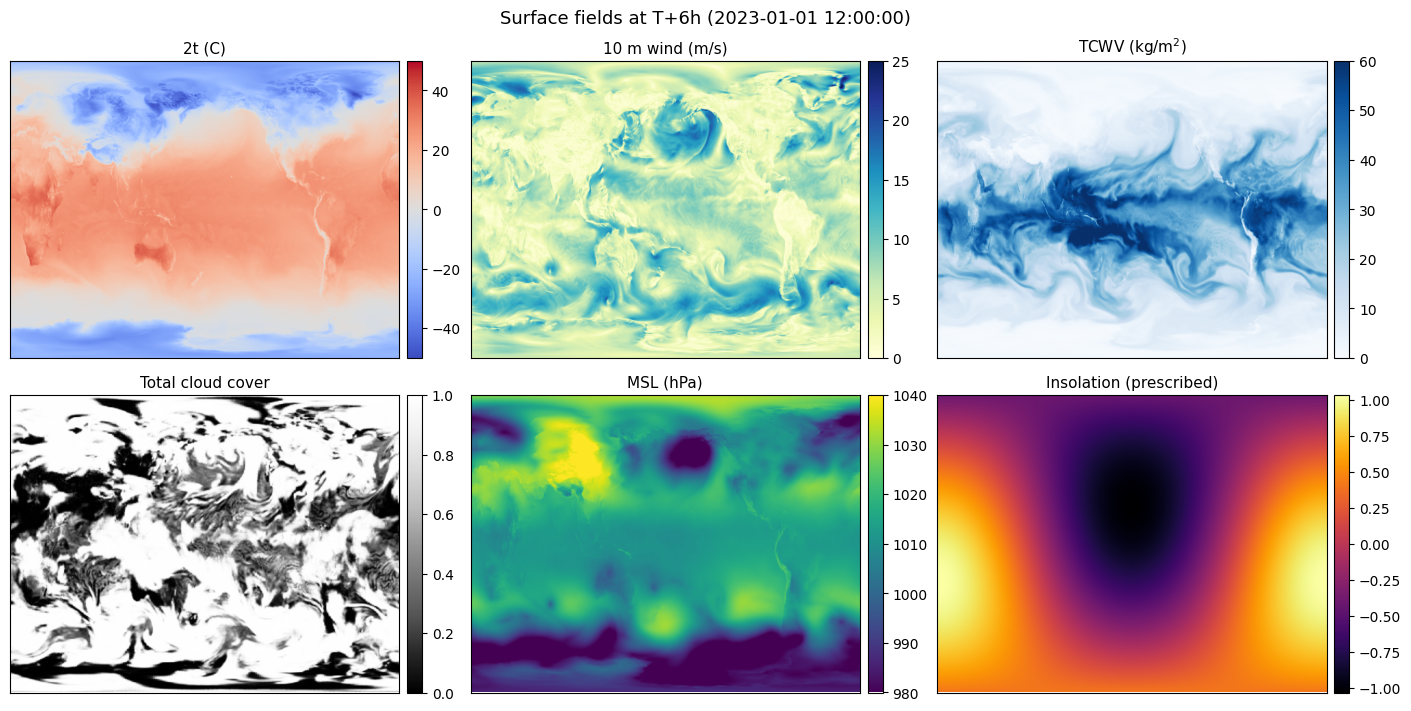

In [8]:
# Multi-field surface snapshot at T+6h (extended V1p5 channels)
pred6 = hourly_preds[LEAD_T6]
u10 = _field_2d(pred6, "10u")
v10 = _field_2d(pred6, "10v")
wind10 = np.hypot(u10, v10)
panels = [
    (_field_2d(pred6, "2t") - 273.15, "2t (C)", "coolwarm", (-50, 50)),
    (wind10, "10 m wind (m/s)", "YlGnBu", (0, 25)),
    (_field_2d(pred6, "tcwv"), "TCWV (kg/m$^2$)", "Blues", (0, 60)),
    (_field_2d(pred6, "tcc"), "Total cloud cover", "Greys_r", (0, 1)),
    (_field_2d(pred6, "msl") / 100.0, "MSL (hPa)", "viridis", (980, 1040)),
    (_field_2d(pred6, "insolation"), "Insolation (prescribed)", "inferno", None),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.0), constrained_layout=True)
for ax, (data, title, cmap, limits) in zip(axes.ravel(), panels):
    vmin, vmax = (None, None) if limits is None else limits
    im = _imshow(ax, data, vmin=vmin, vmax=vmax, cmap=cmap, title=title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle(f"Surface fields at T+6h ({pred6.metadata.time[-1]})", fontsize=13)
plt.show()


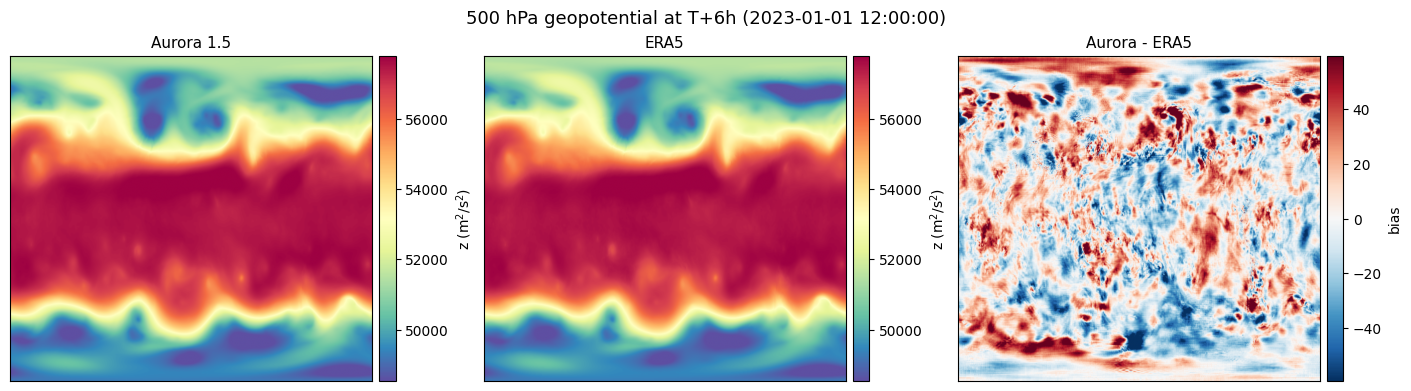

In [9]:
# 500 hPa geopotential: Aurora | ERA5 | bias at T+6h
pred6 = hourly_preds[LEAD_T6]
z_aurora = _atmos_level(pred6, "z", 500.0)
z_truth = _match_pred_grid(_era5_z500(ERA5_T12), z_aurora)
z_bias = z_aurora - z_truth

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
vmin = float(np.nanpercentile(np.stack([z_aurora, z_truth]), 2))
vmax = float(np.nanpercentile(np.stack([z_aurora, z_truth]), 98))
im0 = _imshow(axes[0], z_aurora, vmin=vmin, vmax=vmax, cmap="Spectral_r", title="Aurora 1.5")
im1 = _imshow(axes[1], z_truth, vmin=vmin, vmax=vmax, cmap="Spectral_r", title="ERA5")
bias_lim = float(np.nanpercentile(np.abs(z_bias), 98))
im2 = _imshow(axes[2], z_bias, vmin=-bias_lim, vmax=bias_lim, cmap="RdBu_r", title="Aurora - ERA5")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label="z (m$^2$/s$^2$)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label="z (m$^2$/s$^2$)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02, label="bias")
fig.suptitle(f"500 hPa geopotential at T+6h ({pred6.metadata.time[-1]})", fontsize=13)
plt.show()


## 5. Ensemble members (optional)

Use preset `aurora_v1p5_ensemble`. Like upstream, generate members by repeating rollout and calling `reset_noise()` between members. With fine leads, keep `use_noise_accumulation=True` (Engine default). The next cell plots ensemble mean and spread at T+6h when members are available.


In [10]:
ENSEMBLE_PRESET = "aurora_v1p5_ensemble"
ENSEMBLE_MEMBERS = 2

ens_variant = DEFAULT_PRESETS.get(ENSEMBLE_PRESET).variant
ens_ckpt = ASSET_ROOT / ens_variant.checkpoint_filename
ens_checkpoint_arg = ens_ckpt if ens_ckpt.is_file() else None
ens_allow_hub = ens_checkpoint_arg is None
ens_hf_endpoint = (
    (HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None) if ens_allow_hub else None
)

ensemble_engine = AuroraEngine.from_preset(
    ENSEMBLE_PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=ens_checkpoint_arg,
    allow_hub_download=ens_allow_hub,
    hf_endpoint=ens_hf_endpoint,
)
ensemble_engine.load(rollout_steps=ROLLOUT_STEPS)
print("loaded ensemble model:", type(ensemble_engine.model).__name__)

member_forecasts = []
for member in range(ENSEMBLE_MEMBERS):
    ensemble_engine.model.reset_noise()
    member_preds = [
        pred.to("cpu")
        for pred in ensemble_engine.rollout_stream(
            batch,
            ROLLOUT_STEPS,
            fine_lead_times=FINE_LEAD_TIMES,
            use_noise_accumulation=True,
        )
    ]
    member_forecasts.append(member_preds)
    print(f"member {member}: {len(member_preds)} yields, last time {member_preds[-1].metadata.time[-1]}")


loaded ensemble model: AuroraV1p5Ensemble
member 0: 12 yields, last time 2023-01-01 18:00:00
member 1: 12 yields, last time 2023-01-01 18:00:00


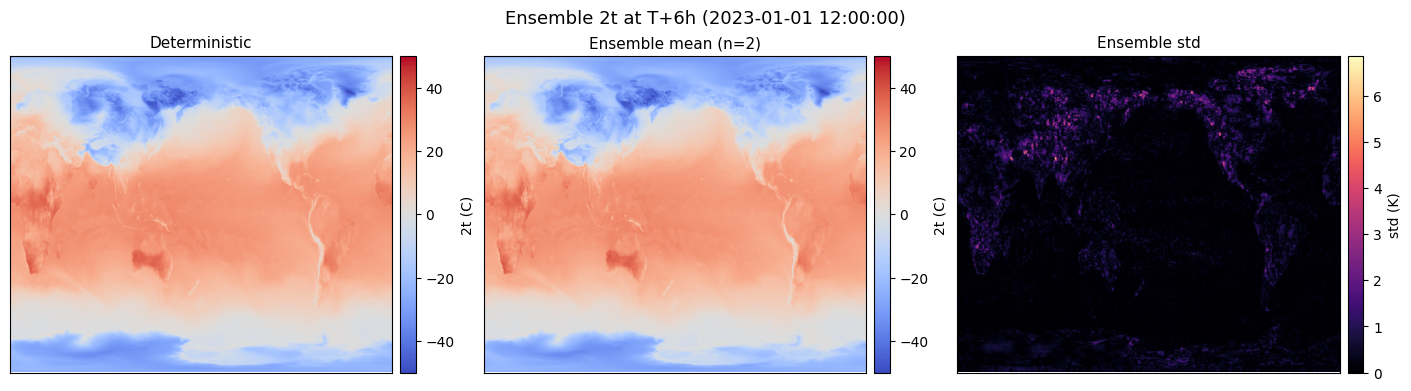

In [11]:
# Ensemble mean / spread of 2t at T+6h (skip if ensemble cell was not run)
if "member_forecasts" not in globals() or not member_forecasts:
    print("Skip ensemble plot: run the ensemble cell first (requires aurora-0.25-v1.5-ensemble.ckpt).")
else:
    member_t2m = np.stack(
        [_field_2d(member[LEAD_T6], "2t") - 273.15 for member in member_forecasts],
        axis=0,
    )
    ens_mean = member_t2m.mean(axis=0)
    ens_std = member_t2m.std(axis=0)
    det_t2m = _field_2d(hourly_preds[LEAD_T6], "2t") - 273.15

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
    im0 = _imshow(axes[0], det_t2m, vmin=-50, vmax=50, cmap="coolwarm", title="Deterministic")
    im1 = _imshow(axes[1], ens_mean, vmin=-50, vmax=50, cmap="coolwarm", title=f"Ensemble mean (n={len(member_forecasts)})")
    im2 = _imshow(axes[2], ens_std, vmin=0, vmax=max(1.0, float(ens_std.max())), cmap="magma", title="Ensemble std")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label="2t (C)")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label="2t (C)")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02, label="std (K)")
    fig.suptitle(f"Ensemble 2t at T+6h ({hourly_preds[LEAD_T6].metadata.time[-1]})", fontsize=13)
    plt.show()
